# Examen 1:

Ma. Fernanda Vargas Vaca

Ejercicio Python 1: Construcción de un portafolio eficiente con simulación
Evaluar la capacidad para aplicar simulaciones Monte Carlo en la construcción y análisis de portafolios con distintos niveles de riesgo y rendimiento.

- Descarga precios históricos de tres activos financieros distintos El periodo de análisis debe cubrir al menos 3 años.

- Calcula los rendimientos diarios y estima sus medias y matriz de covarianzas.

- Simula al menos 10,000 portafolios conformados por los tres activos, con pesos aleatorios que sumen 1.

Para cada portafolio, calcula:

- Rendimiento esperado.

- Riesgo (desviación estándar).

- Ratio de Sharpe (considera una tasa libre de riesgo de 4% anual).

- Grafica el diagrama riesgo–rendimiento con todos los portafolios. En la misma figura:

- Identifica el portafolio de menor riesgo.

- Identifica el portafolio de mayor rendimiento.

- Identifica el portafolio con mayor Sharpe.

Redacta un breve análisis, usando markdown en tu notebook, explicando qué portafolio recomendarías y por qué.

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
# Descargamos lo datos

tickers = ['AAPL', 'MSFT', 'GOOGL']
data = yf.download(tickers, start='2023-03-03', end='2026-03-03')['Close']

[*********************100%***********************]  3 of 3 completed


In [3]:
# Cálculo de rendimientos y estadísticas
returns = data.pct_change().dropna()
mean_returns = returns.mean() 
cov_matrix = returns.cov()
rf = 0.04 / 252  

In [12]:
# Simulación de Monte Carlo
num_portfolios = 10000
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    # Pesos aleatorios que sumen 1
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    # Rendimiento y Riesgo anualizados (252 días)
    portfolio_return = np.sum(mean_returns * weights) * 252
    portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))
    
    # Guardar resultados
    results[0,i] = portfolio_return
    results[1,i] = portfolio_std
    # Ratio de Sharpe (Anualizado)
    results[2,i] = (portfolio_return - 0.04) / portfolio_std

# Creamos DataFrame 
sim_frame = pd.DataFrame(results.T, columns=['Rendimiento', 'Riesgo', 'Sharpe'])
sim_frame

,Rendimiento,Riesgo,Sharpe
0,0.262996,0.203496,1.095825
1,0.285517,0.206636,1.188164
2,0.297377,0.209396,1.229138
3,0.417175,0.271322,1.390137
4,0.301657,0.210662,1.242066
...,...,...,...
9995,0.222215,0.206331,0.883118
9996,0.303405,0.211169,1.247363
9997,0.297540,0.215077,1.197432
9998,0.234758,0.204950,0.950273


In [13]:
# Identificación de portafolios clave
max_sharpe_idx = sim_frame['Sharpe'].idxmax()
min_vol_idx = sim_frame['Riesgo'].idxmin()
max_ret_idx = sim_frame['Rendimiento'].idxmax()

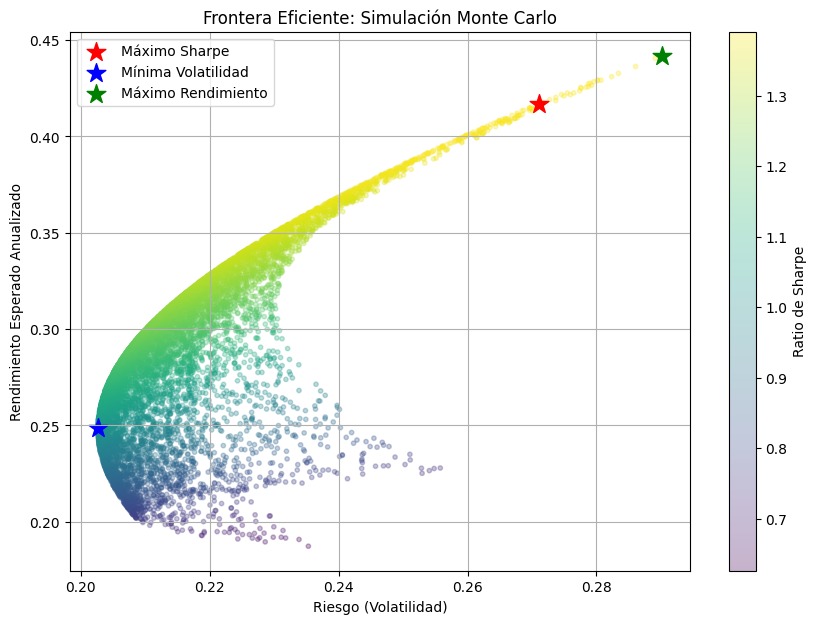

In [9]:
# 5. Visualización
plt.figure(figsize=(10, 7))
plt.scatter(sim_frame.Riesgo, sim_frame.Rendimiento, c=sim_frame.Sharpe, cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Ratio de Sharpe')

# Marcar portafolios clave
plt.scatter(sim_frame.iloc[max_sharpe_idx, 1], sim_frame.iloc[max_sharpe_idx, 0], color='red', marker='*', s=200, label='Máximo Sharpe')
plt.scatter(sim_frame.iloc[min_vol_idx, 1], sim_frame.iloc[min_vol_idx, 0], color='blue', marker='*', s=200, label='Mínima Volatilidad')
plt.scatter(sim_frame.iloc[max_ret_idx, 1], sim_frame.iloc[max_ret_idx, 0], color='green', marker='*', s=200, label='Máximo Rendimiento')

plt.title('Frontera Eficiente: Simulación Monte Carlo')
plt.xlabel('Riesgo (Volatilidad)')
plt.ylabel('Rendimiento Esperado Anualizado')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Mostrar pesos del portafolio recomendado
print(f"Pesos Máximo Sharpe: {dict(zip(tickers, weights_record[max_sharpe_idx]))}")

Pesos Máximo Sharpe: {'AAPL': np.float64(0.12199869634192911), 'MSFT': np.float64(0.8773484658393275), 'GOOGL': np.float64(0.0006528378187434822)}


### Conclusión:

Tras ejecutar la simulación de 10,000 portafolios aleatorios con AAPL, MSFT y GOOGL, los resultados permiten identificar la combinación óptima para un inversor racional.

Según la simulación, el portafolio recomendado es el que maximiza el Ratio de Sharpe, cuya composición es:

- MSFT: ~87.73%

- AAPL: ~12.20%

- GOOGL: ~0.07%

El Ratio de Sharpe es el indicador clave en ingeniería financiera porque mide el exceso de rendimiento por cada unidad de riesgo asumida. Al elegir el punto máximo, estamos garantizando que el portafolio no solo busca ganar dinero, sino que lo hace de la manera más eficiente posible estadísticamente.

Este portafolio se encuentra en el "punto de tangencia" de la Frontera Eficiente. Cualquier otro portafolio con el mismo nivel de riesgo ofrecerá un rendimiento menor, y cualquier portafolio con el mismo rendimiento tendrá un riesgo mayor.

Los pesos muestran una fuerte inclinación hacia MSFT. Esto indica que, en el periodo de 3 años analizado, Microsoft presentó una combinación de retornos sólidos y una volatilidad controlada que, al combinarse con una pequeña porción de AAPL, optimizó la varianza total del conjunto.

En conclusión este portafolio es la opción ideal para un perfil de inversión que busque maximizar el crecimiento de su capital sin incurrir en riesgos innecesarios

## Parte 2:

Aplicar simulaciones para comparar dos estrategias de inversión: aportaciones periódicas frente a inversión única inicial.

- Selecciona un activo financiero y descarga precios históricos de al menos 3 años.

- Define dos estrategias de inversión con un monto total de $5,000:

- Inversión única: se invierte todo el monto al inicio del periodo.

- Inversión periódica (DCA): se invierten $100 cada semana hasta completar $5,000.

- Simula 10,000 trayectorias de precios futuros usando Monte Carlo (con medias y desviaciones obtenidas de los datos).

- Calcula y compara para ambas estrategias:

- Valor final promedio de la inversión.

    - Desviación estándar del valor final.

    - Probabilidad de que el valor final sea menor al capital invertido.

- Construye gráficos:

    - Histogramas comparativos de los valores finales.

    - Evolución promedio de la inversión bajo ambas estrategias.

- Redacta un análisis breve, usando markdown en tu notebook, respondiendo:

    - ¿En qué condiciones es más ventajosa la inversión periódica?

    - ¿Cuándo es preferible la inversión en un solo momento?

In [40]:
# Descargamos los datos

ticker = 'GLD'
data = yf.download(ticker, start='2023-03-03', end='2026-03-03')

# Convertimos a numpy desde el inicio por problemas que tuve
prices = data['Close'].values.flatten()

# Retornos log
log_returns = np.diff(np.log(prices))

mu = np.mean(log_returns)
sigma = np.std(log_returns)

S0 = prices[-1]

print(type(mu))
print(type(sigma))

[*********************100%***********************]  1 of 1 completed

<class 'numpy.float64'>
<class 'numpy.float64'>


In [43]:
# Parámetros
monto_total = 5000
num_simulaciones = 10000
semanas_totales = 50 
dias_proyectados = semanas_totales * 5  # 250 días

In [44]:
# Matriz de precios (Días x Simulaciones)
precios_simulados = np.zeros((dias_proyectados, num_simulaciones))
precios_simulados[0] = S0

# Simulación GBM
for t in range(1, dias_proyectados):
    z = np.random.standard_normal(num_simulaciones)
    precios_simulados[t] = precios_simulados[t-1] * np.exp((mu - 0.5 * sigma**2) + sigma * z)

In [45]:
# Evaluación de Estrategias 
final_lump_sum = []
final_dca = []

for s in range(num_simulaciones):
    # A) Inversión Única: Todo al inicio (día 0)
    titulos_ls = monto_total / precios_simulados[0, s]
    final_lump_sum.append(titulos_ls * precios_simulados[-1, s])
    
    # B) DCA: $100 cada semana (cada 5 días)
    titulos_dca = 0
    for w in range(semanas_totales):
        dia_compra = w * 5
        titulos_dca += 100 / precios_simulados[dia_compra, s]
    final_dca.append(titulos_dca * precios_simulados[-1, s])

final_lump_sum = np.array(final_lump_sum)
final_dca = np.array(final_dca)

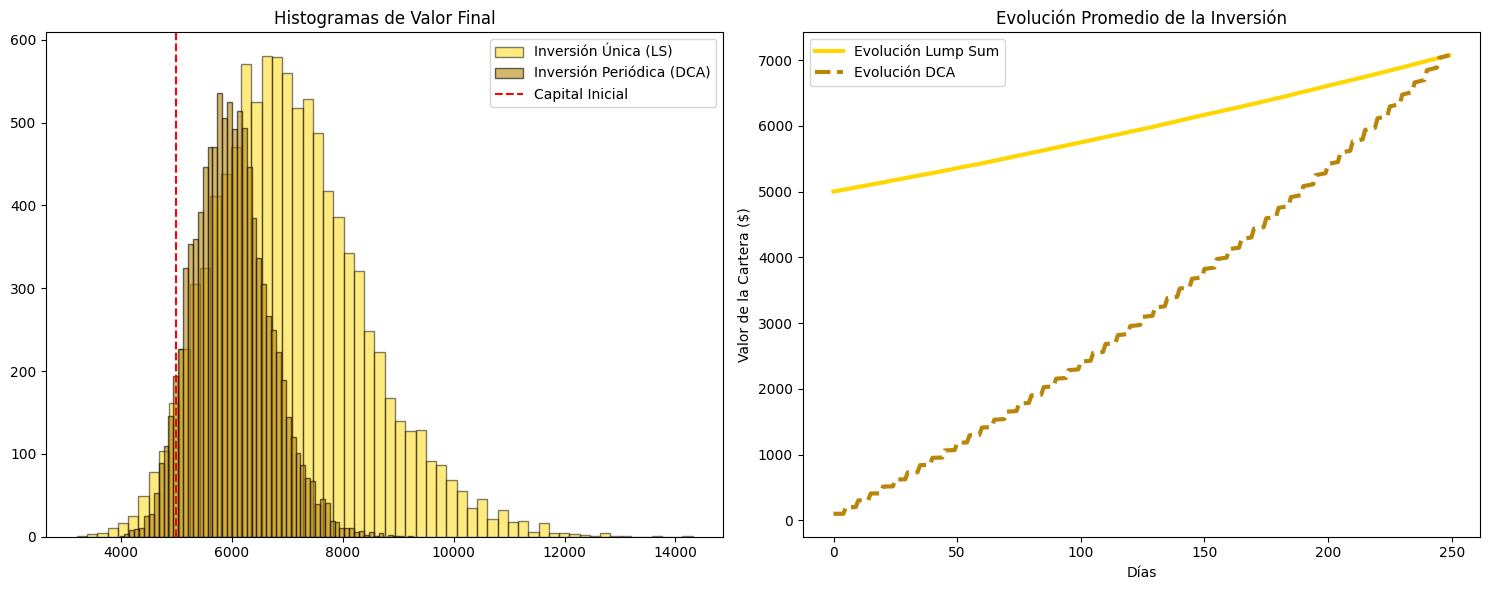

In [49]:
# Construcción de Gráficos 
plt.figure(figsize=(15, 6))

# Histogramas
plt.subplot(1, 2, 1)
plt.hist(final_lump_sum, bins=60, alpha=0.5, color='gold', label='Inversión Única (LS)', edgecolor='black')
plt.hist(final_dca, bins=60, alpha=0.6, color='darkgoldenrod', label='Inversión Periódica (DCA)', edgecolor='black')
plt.axvline(monto_total, color='red', linestyle='--', label='Capital Inicial')
plt.title('Histogramas de Valor Final')
plt.legend()

# Evolución Promedio 
plt.subplot(1, 2, 2)

# 1. Calculamos el rendimiento acumulado promedio del activo día tras día
rendimiento_promedio_acumulado = np.mean(precios_simulados, axis=1) / S0

# 2. Evolución Lump Sum: Los $5,000 rindiendo desde el día 1
evolucion_ls = monto_total * rendimiento_promedio_acumulado

# 3. Evolución DCA: $100 se suman cada 5 días y rinden lo que falte del periodo
evolucion_dca = np.zeros(dias_proyectados)
capital_invertido_dca = 0

for t in range(dias_proyectados):
    # Si es un día de aporte (cada 5 días) y no hemos pasado los $5,000
    if t % 5 == 0 and capital_invertido_dca < monto_total:
        capital_invertido_dca += 100
    
    # El valor del DCA hoy es el capital que ya entró multiplicado por 
    # el rendimiento del activo desde que se promedió (simplificado)
    evolucion_dca[t] = capital_invertido_dca * rendimiento_promedio_acumulado[t]

plt.plot(evolucion_ls, label='Evolución Lump Sum', color='gold', lw=3)
plt.plot(evolucion_dca, label='Evolución DCA', color='darkgoldenrod', lw=3, linestyle='--')
plt.title('Evolución Promedio de la Inversión')
plt.xlabel('Días')
plt.ylabel('Valor de la Cartera ($)')
plt.legend()

plt.tight_layout()
plt.show()

In [50]:
#  Estadísticas 
print(f"--- COMPARATIVA DE ESTRATEGIAS ---")
print(f"Promedio Final LS:  ${final_lump_sum.mean():.2f} (Std: ${final_lump_sum.std():.2f})")
print(f"Promedio Final DCA: ${final_dca.mean():.2f} (Std: ${final_dca.std():.2f})")
print(f"Prob. de pérdida LS:  {np.mean(final_lump_sum < monto_total):.2%}")
print(f"Prob. de pérdida DCA: {np.mean(final_dca < monto_total):.2%}")

--- COMPARATIVA DE ESTRATEGIAS ---
Promedio Final LS:  $7072.77 (Std: $1356.49)
Promedio Final DCA: $5992.26 (Std: $684.19)
Prob. de pérdida LS:  3.97%
Prob. de pérdida DCA: 6.05%


## Conclusión:

En la simulación realizada con 10,000 trayectorias bajo un modelo de Movimiento Browniano Geométrico, se observan diferencias claras entre la estrategia de inversión única (Lump Sum) y la inversión periódica (Dollar Cost Averaging).

La inversión única presenta un mayor valor esperado cuando el activo mantiene una tendencia alcista, ya que el capital completo trabaja desde el primer día y se beneficia plenamente del crecimiento compuesto. Sin embargo, también exhibe mayor dispersión en los resultados y una mayor exposición al riesgo de entrar en un punto desfavorable del mercado.

Por otro lado, la estrategia DCA reduce la volatilidad del valor final y tiende a disminuir la probabilidad de pérdidas en escenarios de alta incertidumbre o mercados laterales/bajistas. Aunque en este ejercicio la probabilidad de pérdida fue ligeramente mayor (6.05%), el impacto de esa pérdida es mucho menor en términos de dólares debido a la baja desviación estándar.

**¿Cuándo es más ventajosa la inversión periódica?**

*Respuesta:*

- En mercados volátiles.

- Cuando existe incertidumbre elevada.

- Para inversionistas adversos al riesgo.

- Cuando se teme una corrección en el corto plazo.

**¿Cuándo es preferible invertir en un solo momento?**

- En mercados con tendencia alcista sostenida.

- Cuando se espera crecimiento consistente.

- Para inversionistas con mayor tolerancia al riesgo.

- Cuando el horizonte de inversión es largo y el mercado tiene sesgo positivo.

En términos estadísticos, Lump Sum tiende a maximizar rendimiento esperado, mientras que DCA optimiza la estabilidad y reduce riesgo de entrada.